<img src="../../images/bwHPC_Logo_cmyk.svg" width="200" /> <img src="../../images/HochschuleEsslingen_Logo_RGB_DE.png" width="200" /> <img src="../../images/Konstanz_Logo.svg" width="200" /> <img src="../../images/KIT_Logo.png" width="200" />

# Tensors and Autograd

Everything in `01_TensorFlow` was built with Keras, where a network is a list of
layers and `fit()` does the rest. **PyTorch** is the other framework you are likely
to meet, and it works at a noticeably lower level.

That is a deliberate design choice, not a shortcoming. In Keras the training loop is
hidden inside `fit()`; in PyTorch you normally **write the loop yourself** — forward
pass, loss, gradients, update — which is more code, but leaves every step visible and
changeable. Researchers tend to prefer that; it is why most new papers ship PyTorch
code.

> **If you have not worked through the TensorFlow notebooks yet, do those first.**
> They introduce the ideas — neurons, layers, activation functions, loss, gradient
> descent, batches, epochs — with far less machinery in the way. This chapter assumes
> you know them and concentrates on how PyTorch expresses them.

### How this chapter is built

To show what PyTorch's tools actually do for you, we do things the hard way first and
then remove the hard work step by step:

1. **this notebook** — write a model and its gradients by hand, then let PyTorch's
   autograd compute them
2. **02** — a working digit classifier, with no PyTorch neural-network machinery at
   all
3. **03** — the same classifier, refactored piece by piece using `torch.nn`,
   `torch.optim`, `Dataset` and `DataLoader`
4. **04** — a convolutional network, and the reusable training loop that falls out
   of the refactoring

By the end, three lines of code will do what the second notebook needs fifty for —
and because you will have written those fifty, you will know exactly what the three
are hiding.

---

## Contents

1. [The task](#task)
2. [Doing it by hand in NumPy](#numpy)
3. [The same thing with PyTorch tensors](#tensors)
4. [Letting autograd do the gradients](#autograd)

<a id="task"></a>
## 1. The task

Before any neural network, a smaller problem with the same shape.

We approximate **sin(x)** between −π and π with a third-degree polynomial:

$$\hat y = a + b\,x + c\,x^{2} + d\,x^{3}$$

Four numbers — `a`, `b`, `c`, `d` — have to be chosen so the curve sits as close to
the sine as possible. Which is exactly the situation a neural network is in: adjust
some parameters until the output matches the target.

In fact this *is* a neural network, drawn differently:

![A polynomial as a network](../../images/pt_polynomial_network.svg)

Four inputs (the powers of x), four weights, one output, no hidden layer and no
activation function. Small enough that we can compute every gradient by hand.

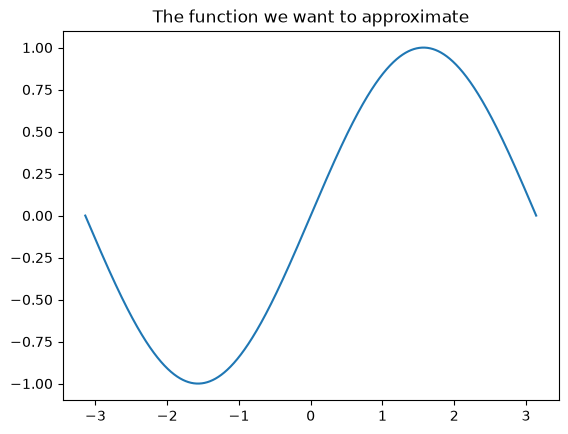

In [1]:
import math

import numpy as np
import matplotlib.pyplot as plt

x = np.linspace(-math.pi, math.pi, 2000)
y_reference = np.sin(x)

plt.plot(x, y_reference)
plt.title("The function we want to approximate")
plt.show()

<a id="numpy"></a>
## 2. Doing it by hand in NumPy

No framework at all to begin with — just NumPy. This makes the pieces explicit, and
every one of them will reappear later under a PyTorch name.

Start from four random weights and a learning rate.

In [2]:
np.random.seed(0)

a = np.random.randn()
b = np.random.randn()
c = np.random.randn()
d = np.random.randn()

learning_rate = 1e-6

Now the training loop, which does three things per iteration:

1. **forward pass** — compute the prediction from the current weights
2. **loss** — measure how far it is from the target, as a sum of squared errors
3. **backpropagation** — work out, for each weight, which direction reduces the loss,
   and take a small step that way

The gradients here are written out by hand. For `a` the derivative of the loss is
just the sum of the errors; for `b` it is the errors weighted by `x`; and so on.
Doing this for four weights is a minor annoyance. Doing it for a network with
thousands is where it becomes impossible.

In [3]:
for t in range(2000):
    # forward pass: y = a + b x + c x^2 + d x^3
    y_pred = a + b * x + c * x ** 2 + d * x ** 3

    loss = np.square(y_pred - y_reference).sum()
    if t % 500 == 499:
        print(f"iteration {t + 1:>5}   loss {loss:.4f}")

    # gradients of the loss with respect to each weight, worked out by hand
    grad_y_pred = 2.0 * (y_pred - y_reference)
    grad_a = grad_y_pred.sum()
    grad_b = (grad_y_pred * x).sum()
    grad_c = (grad_y_pred * x ** 2).sum()
    grad_d = (grad_y_pred * x ** 3).sum()

    # take a step downhill
    a -= learning_rate * grad_a
    b -= learning_rate * grad_b
    c -= learning_rate * grad_c
    d -= learning_rate * grad_d

print(f"\nResult: y = {a:.4f} + {b:.4f} x + {c:.4f} x^2 + {d:.4f} x^3")
y_numpy = y_pred

iteration   500   loss 468.8488
iteration  1000   loss 86.3758
iteration  1500   loss 22.0652
iteration  2000   loss 11.1030

Result: y = 0.0488 + 0.8444 x + -0.0084 x^2 + -0.0916 x^3


<a id="tensors"></a>
## 3. The same thing with PyTorch tensors

Now the identical calculation in PyTorch.

PyTorch's basic object is the **tensor**, which is close enough to a NumPy array that
most of the code carries over unchanged — the function names were chosen to match.
What a tensor adds is that it can live on a **GPU**, and that it can record what was
done to it, which is the subject of the next section.

Because PyTorch supports several kinds of accelerator, it is usual to name the device
explicitly and pass it when creating tensors.

In [4]:
import torch

dtype = torch.float
device = torch.device("cpu")
# device = torch.device("cuda:0")   # uncomment to run on an NVIDIA GPU

x_t = torch.linspace(-math.pi, math.pi, 2000, device=device, dtype=dtype)
y_t = torch.sin(x_t)

torch.manual_seed(0)
a = torch.randn((), device=device, dtype=dtype)
b = torch.randn((), device=device, dtype=dtype)
c = torch.randn((), device=device, dtype=dtype)
d = torch.randn((), device=device, dtype=dtype)

The loop is the NumPy one with the names changed. `.pow(2)` replaces `np.square`,
and `.item()` pulls a plain Python number out of a one-element tensor.

In [5]:
learning_rate = 1e-6

for t in range(2000):
    y_pred = a + b * x_t + c * x_t ** 2 + d * x_t ** 3

    loss = (y_pred - y_t).pow(2).sum().item()
    if t % 500 == 499:
        print(f"iteration {t + 1:>5}   loss {loss:.4f}")

    grad_y_pred = 2.0 * (y_pred - y_t)
    grad_a = grad_y_pred.sum()
    grad_b = (grad_y_pred * x_t).sum()
    grad_c = (grad_y_pred * x_t ** 2).sum()
    grad_d = (grad_y_pred * x_t ** 3).sum()

    a -= learning_rate * grad_a
    b -= learning_rate * grad_b
    c -= learning_rate * grad_c
    d -= learning_rate * grad_d

print(f"\nResult: y = {a.item():.4f} + {b.item():.4f} x + "
      f"{c.item():.4f} x^2 + {d.item():.4f} x^3")
y_torch = y_pred

iteration   500   loss 756.6681
iteration  1000   loss 131.3757
iteration  1500   loss 29.2826
iteration  2000   loss 12.2867

Result: y = 0.0586 + 0.8372 x + -0.0101 x^2 + -0.0906 x^3


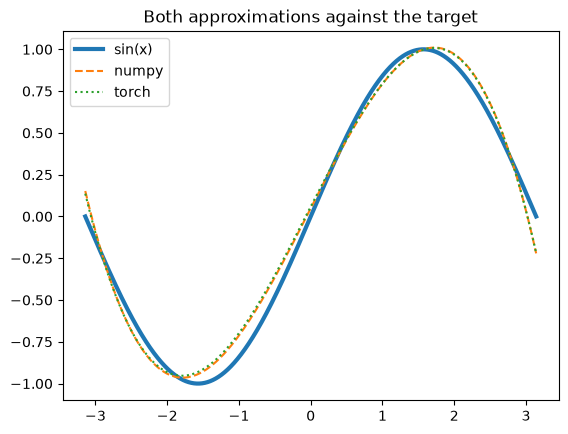

In [6]:
plt.plot(x, y_reference, label="sin(x)", linewidth=3)
plt.plot(x, y_numpy, label="numpy", linestyle="--")
plt.plot(x, y_torch, label="torch", linestyle=":")

plt.title("Both approximations against the target")
plt.legend()
plt.show()

Both land in the same place, which is the point: nothing has been gained yet.
PyTorch has been used as a slightly different NumPy.

<a id="autograd"></a>
## 4. Letting autograd do the gradients

Here is what PyTorch is actually for.

Marking a tensor with **`requires_grad=True`** tells PyTorch to remember every
operation performed on it. Calling **`.backward()`** on the loss then walks that
record backwards and fills in `.grad` for every marked tensor — the same four
derivatives we wrote out by hand, computed automatically.

This is called **automatic differentiation**, or *autograd*. It is what makes
networks with millions of parameters possible: nobody could differentiate those by
hand.

In [7]:
torch.manual_seed(0)

a = torch.randn((), device=device, dtype=dtype, requires_grad=True)
b = torch.randn((), device=device, dtype=dtype, requires_grad=True)
c = torch.randn((), device=device, dtype=dtype, requires_grad=True)
d = torch.randn((), device=device, dtype=dtype, requires_grad=True)

The loop loses its entire gradient section. Two details are worth naming:

- the update happens inside **`torch.no_grad()`**, because adjusting the weights is
  not part of the calculation we want differentiated next time round
- the gradients are **cleared afterwards**. PyTorch *adds* each new gradient to
  whatever is already there, so without clearing they would accumulate across
  iterations

In [8]:
learning_rate = 1e-6

for t in range(2000):
    y_pred = a + b * x_t + c * x_t ** 2 + d * x_t ** 3

    loss = (y_pred - y_t).pow(2).sum()
    if t % 500 == 499:
        print(f"iteration {t + 1:>5}   loss {loss.item():.4f}")

    # one line replaces all four hand-written gradients
    loss.backward()

    with torch.no_grad():
        a -= learning_rate * a.grad
        b -= learning_rate * b.grad
        c -= learning_rate * c.grad
        d -= learning_rate * d.grad

        # reset, otherwise the next backward() adds to these
        a.grad = None
        b.grad = None
        c.grad = None
        d.grad = None

print(f"\nResult: y = {a.item():.4f} + {b.item():.4f} x + "
      f"{c.item():.4f} x^2 + {d.item():.4f} x^3")

iteration   500   loss 756.6681
iteration  1000   loss 131.3757
iteration  1500   loss 29.2826
iteration  2000   loss 12.2867

Result: y = 0.0586 + 0.8372 x + -0.0101 x^2 + -0.0906 x^3


The same answer, with the calculus removed.

A tensor that is being tracked carries its history with it, which shows up if you
look at it directly.

In [9]:
y_pred

tensor([ 0.1362,  0.1307,  0.1251,  ..., -0.2068, -0.2128, -0.2188],
       grad_fn=<AddBackward0>)

`grad_fn` is the record autograd left behind — the last operation that produced this
tensor. Following that chain backwards is exactly what `.backward()` does.

To get at the numbers without the history, use `.detach()`.

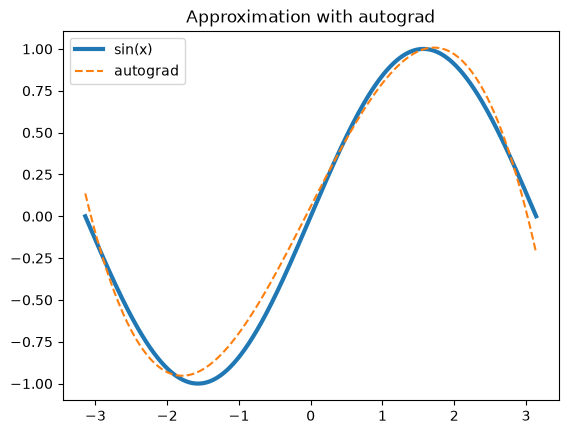

In [10]:
y_autograd = y_pred.detach()

plt.plot(x, y_reference, label="sin(x)", linewidth=3)
plt.plot(x, y_autograd, label="autograd", linestyle="--")

plt.title("Approximation with autograd")
plt.legend()
plt.show()

That is the foundation. Everything from here on is PyTorch removing more of the
work: [notebook 02](02_A_Neural_Network_From_Scratch.ipynb) builds a real classifier
with nothing but tensors and autograd, and the notebooks after that take even the
training loop away.